# Part II: N-Dimensional Optimization
## The N-Dimensional Rosenbrock Function

In N-dimensional space, the Rosenbrock function is defined as:
$$f(x) = \sum_{i=1}^{N-1} [100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2]$$

It has a known global minimum where all variables equal 1: $x^* = (1, 1, \dots, 1)$, and the function value at this minimum is $f(x^*) = 0$.

Because we can no longer plot the landscape, our primary visualization will be tracking the **objective function value $f(x)$** against the **number of iterations**. We will use a logarithmic scale for the y-axis, as algorithms often make massive initial leaps before slowing down in the flat valley.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
np.set_printoptions(precision=4, suppress=True)

def rosenbrock_nd(x):
    """Evaluates the N-dimensional Rosenbrock function."""
    # Using numpy slicing for vectorized computation
    return np.sum(100.0 * (x[1:] - x[:-1]**2.0)**2.0 + (1 - x[:-1])**2.0)

def rosenbrock_grad_nd(x):
    """Evaluates the exact gradient of the N-dimensional Rosenbrock function."""
    grad = np.zeros_like(x)
    
    # First component (index 0)
    grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
    
    # Middle components (indices 1 to N-2)
    if len(x) > 2:
        grad[1:-1] = 200 * (x[1:-1] - x[:-2]**2) - 400 * x[1:-1] * (x[2:] - x[1:-1]**2) - 2 * (1 - x[1:-1])
        
    # Last component (index N-1)
    grad[-1] = 200 * (x[-1] - x[-2]**2)
    
    return grad

def evaluate_convergence(x_final, f_history, algorithm_name):
    """Prints the error and plots the convergence history."""
    # The true solution is an array of ones
    x_true = np.ones_like(x_final)
    
    # Calculate Euclidean distance to the true solution
    distance = np.linalg.norm(x_final - x_true)
    
    print(f"--- {algorithm_name} Results ---")
    print(f"Final f(x): {f_history[-1]:.6e}")
    print(f"Distance to exact solution (1,1,...,1): {distance:.6e}\n")
    
    # Plotting
    plt.figure(figsize=(8, 5))
    plt.plot(f_history, linewidth=2, label=algorithm_name)
    plt.yscale('log')  # Log scale is essential for Rosenbrock
    plt.xlabel('Iteration Number')
    plt.ylabel('Function Value f(x) (Log Scale)')
    plt.title(f'Convergence History: {algorithm_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Set the dimensionality for our experiments
N_DIM = 10
# Standard initialization (often set to 0 or near the origin)
x_start_nd = np.zeros(N_DIM)

print(f"Environment setup complete. N = {N_DIM}.")

Environment setup complete. N = 10.


## 1. Standard Gradient Descent in N-Dimensions

Because the Rosenbrock function has incredibly steep walls forming its valley, a standard fixed-step Gradient Descent requires a profoundly small step size (learning rate) to avoid divergence. This makes its progress through the flat valley floor agonizingly slow. Let's see how it struggles over 10,000 iterations.

--- Standard Gradient Descent Results ---
Final f(x): 2.270938e-05
Distance to exact solution (1,1,...,1): 9.525961e-03



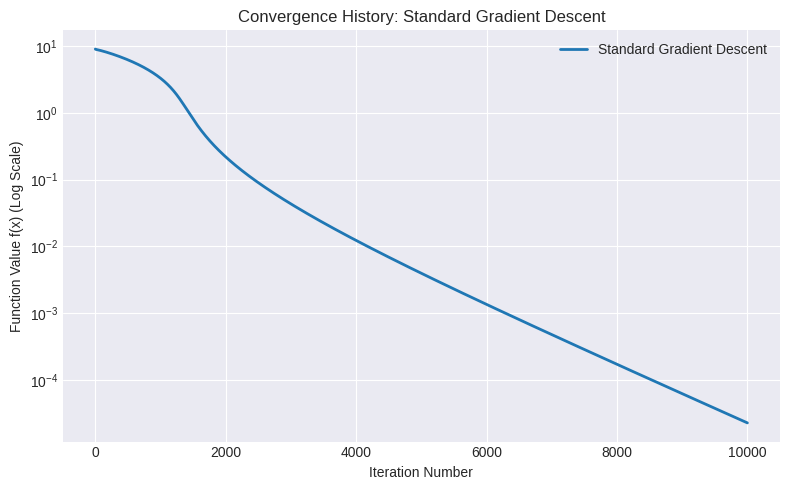

In [3]:
def gradient_descent_nd(f, grad_f, x0, step_size=0.001, max_iter=10000, tol=1e-6):
    """N-dimensional Gradient Descent."""
    x = np.array(x0, dtype=float)
    f_history = [f(x)]
    
    for _ in range(max_iter):
        grad = grad_f(x)
        
        if np.linalg.norm(grad) < tol:
            break
            
        x = x - step_size * grad
        f_history.append(f(x))
        
    return x, np.array(f_history)

# Execute Standard Gradient Descent
# Notice the extremely small step size required to maintain stability
x_final_gd, history_gd = gradient_descent_nd(
    f=rosenbrock_nd, 
    grad_f=rosenbrock_grad_nd, 
    x0=x_start_nd, 
    step_size=0.001, 
    max_iter=10000
)

evaluate_convergence(x_final_gd, history_gd, "Standard Gradient Descent")

## 2. Gradient Descent with Momentum in N-Dimensions

We saw earlier that Momentum helps damp out oscillations across steep ravine walls while accumulating velocity along the flat valley floor. In N-dimensional space, this is precisely what we need to accelerate through the winding Rosenbrock valley. 

By remembering past gradients, the algorithm will naturally correct its course and move toward the $(1, 1, \dots, 1)$ minimum much faster than standard GD.

--- Momentum Gradient Descent Results ---
Final f(x): 1.000014e-12
Distance to exact solution (1,1,...,1): 2.002514e-06



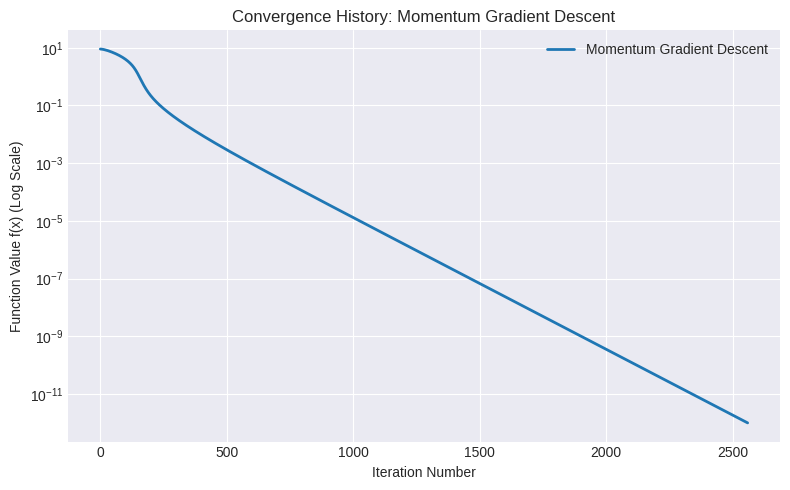

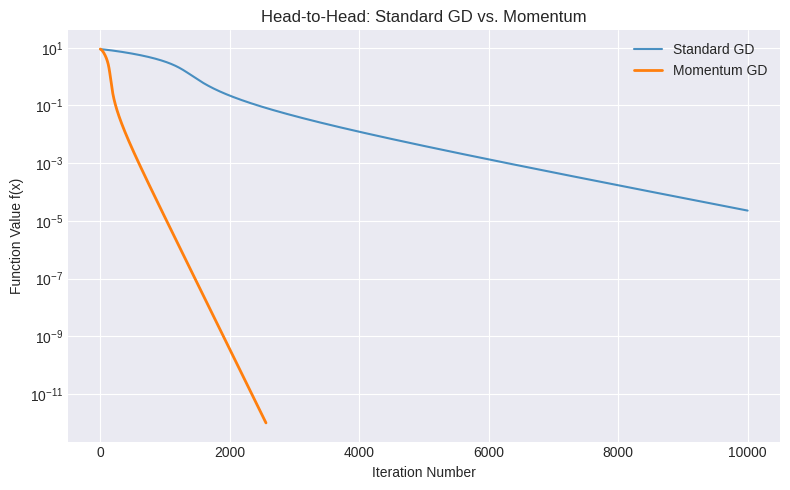

In [4]:
def momentum_gd_nd(f, grad_f, x0, step_size=0.001, beta=0.9, max_iter=10000, tol=1e-6):
    """N-dimensional Gradient Descent with Momentum."""
    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)
    f_history = [f(x)]
    
    for _ in range(max_iter):
        grad = grad_f(x)
        
        if np.linalg.norm(grad) < tol:
            break
            
        # Accumulate velocity and update position
        v = beta * v + step_size * grad
        x = x - v
        
        f_history.append(f(x))
        
    return x, np.array(f_history)

# Execute Momentum Gradient Descent
x_final_mom, history_mom = momentum_gd_nd(
    f=rosenbrock_nd, 
    grad_f=rosenbrock_grad_nd, 
    x0=x_start_nd, 
    step_size=0.001, 
    beta=0.9,
    max_iter=10000
)

evaluate_convergence(x_final_mom, history_mom, "Momentum Gradient Descent")

# Optional: Plot both on the same graph for a direct comparison
plt.figure(figsize=(8, 5))
plt.plot(history_gd, label="Standard GD", alpha=0.8)
plt.plot(history_mom, label="Momentum GD", linewidth=2)
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Function Value f(x)')
plt.title('Head-to-Head: Standard GD vs. Momentum')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Quasi-Newton Methods: The BFGS Algorithm

Newton's method is the gold standard for navigating narrow, winding valleys because it uses the Hessian matrix (second derivatives) to perfectly scale the landscape. However, in N-dimensional space, computing, storing, and inverting the $N \times N$ Hessian matrix at every step is computationally devastating (and sometimes impossible). 

**Quasi-Newton methods** solve this brilliantly. Instead of computing the exact inverse Hessian, they build an *approximation* of it on the fly, using only the history of the first-order gradients!

**How BFGS Works:**
At each iteration, we measure two things:
1. The change in position: $s_k = x_{k+1} - x_k$
2. The change in the gradient: $y_k = \nabla f(x_{k+1}) - \nabla f(x_k)$

By comparing how the gradient changes as we move through space, we can deduce the curvature of the landscape. We use $s_k$ and $y_k$ to update our approximate inverse Hessian matrix ($B \approx H^{-1}$) using the BFGS update formula:
$$B_{k+1} = (I - \rho_k s_k y_k^T) B_k (I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T$$
*(Where $\rho_k = \frac{1}{y_k^T s_k}$ and $I$ is the identity matrix).*

**The Line Search:**
Unlike standard Gradient Descent which can sometimes survive a bad fixed step size, BFGS *requires* a proper Line Search. We must ensure that every step satisfies the "Armijo condition" (ensuring sufficient decrease in the function) so that our curvature approximation remains mathematically sound (positive definite).

Converged beautifully after 73 iterations.
--- BFGS (Quasi-Newton) Results ---
Final f(x): 6.653285e-16
Distance to exact solution (1,1,...,1): 6.393148e-09



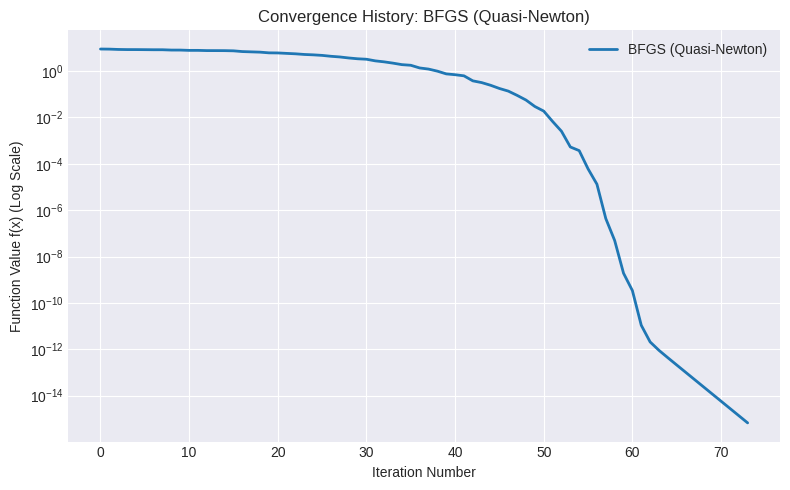

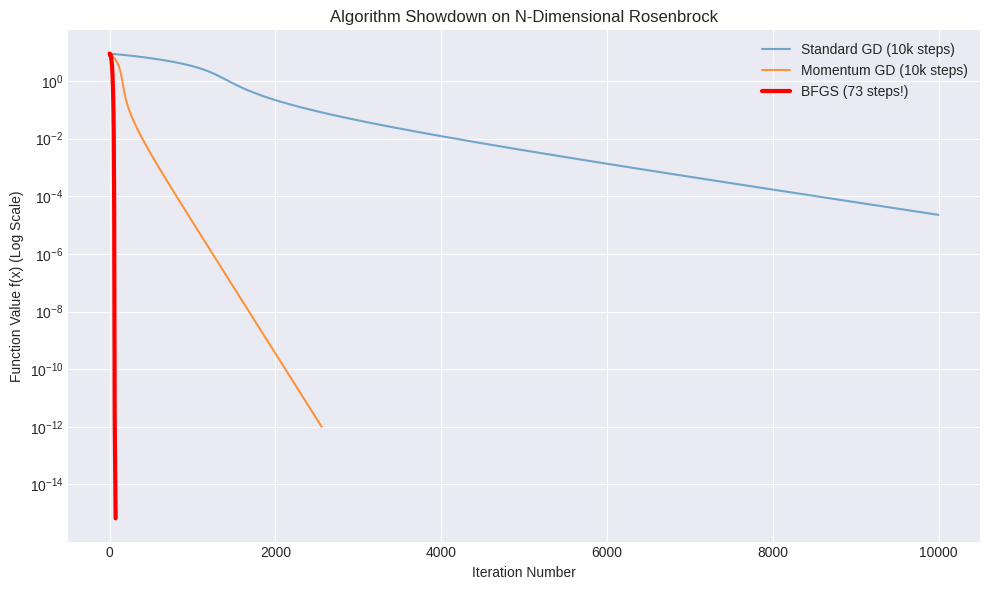

In [5]:
def backtracking_line_search(f, x, p, grad_x, alpha_init=1.0, c=1e-4, tau=0.5):
    """
    Finds a step size alpha that satisfies the Armijo condition.
    """
    alpha = alpha_init
    f_x = f(x)
    # Directional derivative
    m = np.dot(grad_x, p) 
    
    # Backtrack until sufficient decrease is achieved
    while f(x + alpha * p) > f_x + c * alpha * m:
        alpha *= tau
        
        # Failsafe for numerical stability
        if alpha < 1e-10:
            break
            
    return alpha

def bfgs_nd(f, grad_f, x0, max_iter=1000, tol=1e-6):
    """N-dimensional BFGS optimization."""
    x = np.array(x0, dtype=float)
    N = len(x)
    
    # Initialize the inverse Hessian approximation as the Identity matrix
    B_inv = np.eye(N)
    
    f_history = [f(x)]
    
    for i in range(max_iter):
        grad = grad_f(x)
        
        if np.linalg.norm(grad) < tol:
            print(f"Converged beautifully after {i} iterations.")
            break
            
        # 1. Compute search direction (p = -B_inv * grad)
        p = -np.dot(B_inv, grad)
        
        # 2. Line search to find optimal step size
        alpha = backtracking_line_search(f, x, p, grad)
        
        # 3. Update position
        x_new = x + alpha * p
        
        # 4. Compute differences for the BFGS update
        s = x_new - x
        grad_new = grad_f(x_new)
        y = grad_new - grad
        
        # 5. BFGS Inverse Hessian Update
        sy = np.dot(s, y)
        
        # Curvature condition check (ensures positive definiteness)
        if sy > 1e-10: 
            rho = 1.0 / sy
            I = np.eye(N)
            
            # Using np.outer for the outer product of two vectors
            A1 = I - rho * np.outer(s, y)
            A2 = I - rho * np.outer(y, s)
            
            B_inv = np.dot(A1, np.dot(B_inv, A2)) + rho * np.outer(s, s)
            
        x = x_new
        f_history.append(f(x))
        
    else:
        print(f"Reached max iterations ({max_iter}).")
        
    return x, np.array(f_history)

# Execute BFGS
# Notice we only give it 1000 max iterations compared to the 10,000 we gave GD!
x_final_bfgs, history_bfgs = bfgs_nd(
    f=rosenbrock_nd, 
    grad_f=rosenbrock_grad_nd, 
    x0=x_start_nd, 
    max_iter=1000
)

evaluate_convergence(x_final_bfgs, history_bfgs, "BFGS (Quasi-Newton)")

# For maximum impact, let's plot all three together
plt.figure(figsize=(10, 6))
plt.plot(history_gd, label="Standard GD (10k steps)", alpha=0.6)
plt.plot(history_mom, label="Momentum GD (10k steps)", alpha=0.8)
plt.plot(history_bfgs, label=f"BFGS ({len(history_bfgs)-1} steps!)", linewidth=3, color='red')
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Function Value f(x) (Log Scale)')
plt.title('Algorithm Showdown on N-Dimensional Rosenbrock')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Stochastic Gradient Descent (SGD)

In real-world machine learning, our objective function $f(x)$ is usually an average of errors (losses) over a massive dataset of $M$ examples:
$$f(x) = \frac{1}{M} \sum_{i=1}^{M} f_i(x)$$

Computing the exact gradient $\nabla f(x)$ requires evaluating all $M$ examples. If $M = 1,000,000$, a single step takes forever. 

**The Stochastic Shortcut:**
Instead of computing the full gradient, we randomly pick a single example (or a small "mini-batch") at each step and compute the gradient of *just that term*. 
$$x_{k+1} = x_k - \alpha \nabla f_{i_{random}}(x_k)$$

This acts as an **unbiased estimator** of the true gradient. It is incredibly fast to compute, but it injects a massive amount of **noise** into the trajectory. The algorithm will bounce around wildly, but on average, it will drift towards the minimum. 

**Decomposing the Rosenbrock Function:**
To simulate a "dataset" with our N-dimensional Rosenbrock function, we can break its summation into $N-1$ individual terms, treating each term as a separate "data point":
$$f_i(x) = 100(x_{i+1} - x_i^2)^2 + (1 - x_i)^2$$

At each iteration, we will roll a multi-sided die, pick one index $i$, and update our position based *only* on the gradient of $f_i(x)$.

Running Stochastic Gradient Descent...
--- Stochastic Gradient Descent Results ---
Final f(x): 4.007534e-03
Distance to exact solution (1,1,...,1): 1.238179e-01



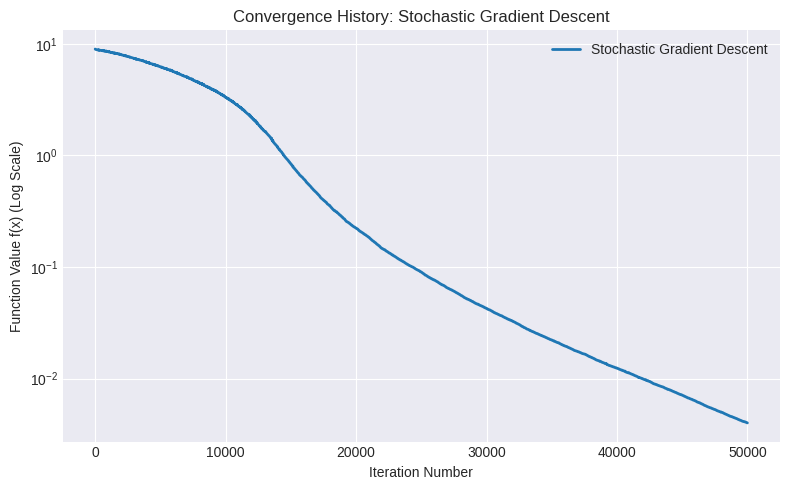

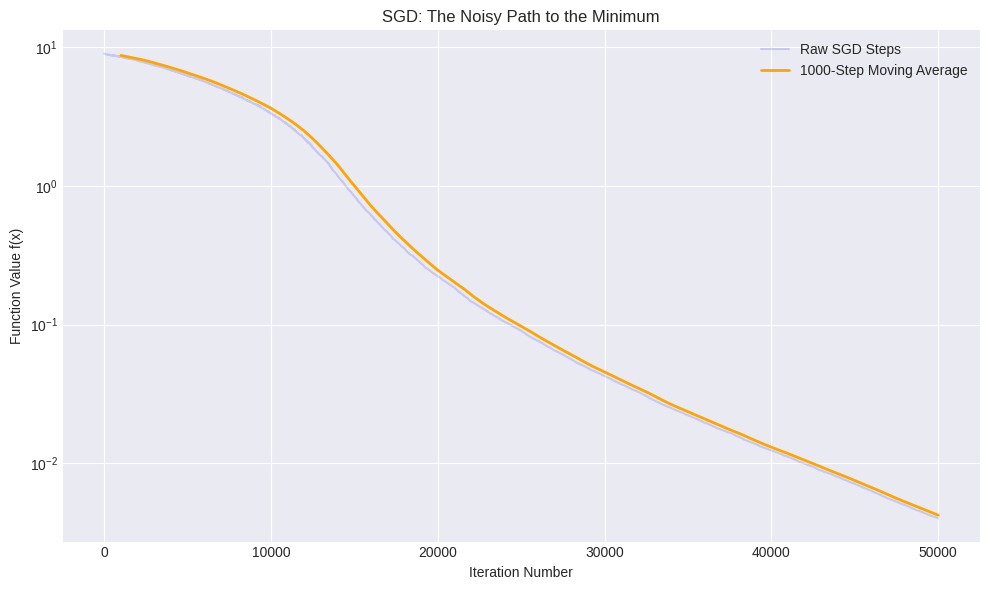

In [6]:
def rosenbrock_sgd_grad(x, i):
    """
    Computes the gradient of a single term f_i(x) of the Rosenbrock function.
    This simulates calculating the gradient for a single 'data point'.
    """
    N = len(x)
    grad = np.zeros(N)
    
    # The gradient of f_i(x) only affects variables x[i] and x[i+1]
    grad[i] = -400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
    grad[i+1] = 200 * (x[i+1] - x[i]**2)
    
    # To make this an unbiased estimator of the full gradient sum, 
    # we must scale it by the total number of terms (N-1)
    return grad * (N - 1)

def sgd_nd(f, x0, step_size=0.0001, max_iter=50000):
    """N-dimensional Stochastic Gradient Descent."""
    x = np.array(x0, dtype=float)
    N = len(x)
    f_history = np.zeros(max_iter + 1)
    f_history[0] = f(x)
    
    for k in range(max_iter):
        # Pick a random "data point" (an index from 0 to N-2)
        idx = np.random.randint(0, N - 1)
        
        # Compute the noisy stochastic gradient
        stochastic_grad = rosenbrock_sgd_grad(x, idx)
        
        # Update position
        x = x - step_size * stochastic_grad
        
        # Log the TRUE full function value to monitor the actual progress
        f_history[k+1] = f(x)
        
    return x, f_history

# Execute SGD
# Because each step is so cheap, we can easily run 50,000 iterations!
# We use a very small step size to prevent the noise from causing divergence.
print("Running Stochastic Gradient Descent...")
x_final_sgd, history_sgd = sgd_nd(
    f=rosenbrock_nd, 
    x0=x_start_nd, 
    step_size=0.0001, 
    max_iter=50000
)

evaluate_convergence(x_final_sgd, history_sgd, "Stochastic Gradient Descent")

# ---------------------------------------------------------
# Advanced Visualization: The Noise Profile of SGD
# ---------------------------------------------------------
# To properly see the "stochastic" nature, let's plot the raw noisy history 
# alongside a smoothed moving average.
def plot_sgd_noise_profile(history):
    plt.figure(figsize=(10, 6))
    
    # Plot raw noisy trajectory (highly transparent)
    plt.plot(history, color='blue', alpha=0.15, label='Raw SGD Steps')
    
    # Calculate a moving average to show the true trend
    window = 1000
    if len(history) > window:
        moving_avg = np.convolve(history, np.ones(window)/window, mode='valid')
        # Pad the moving average so it aligns properly on the x-axis
        x_align = np.arange(window-1, len(history))
        plt.plot(x_align, moving_avg, color='orange', linewidth=2, label=f'{window}-Step Moving Average')

    plt.yscale('log')
    plt.xlabel('Iteration Number')
    plt.ylabel('Function Value f(x)')
    plt.title('SGD: The Noisy Path to the Minimum')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_sgd_noise_profile(history_sgd)

## 5. Adam (Adaptive Moment Estimation)

Standard Gradient Descent applies the exact same step size (learning rate) to every dimension. In the N-dimensional Rosenbrock valley, this is a disaster: the walls are incredibly steep (requiring a tiny step size), but the valley floor is mostly flat (requiring a massive step size). 

**Adam** solves this by maintaining a separate, adaptive learning rate for every single parameter. It combines the benefits of two other extensions: **Momentum** and **RMSProp**.

**The Mathematics:**
At each time step $t$, Adam keeps track of two "moments" of the gradient $g_t$:

1. **The First Moment ($m_t$):** The exponentially decaying average of past gradients (This is just **Momentum**).
   $$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$$
2. **The Second Moment ($v_t$):** The exponentially decaying average of past *squared* gradients. This tracks the uncentered variance (how wild or steep the gradient is in each dimension).
   $$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

**Bias Correction:**
Because $m$ and $v$ are initialized to zero, they are biased toward zero in the early steps. Adam corrects this using the current time step $t$:
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t} \quad \text{and} \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**The Update Rule:**
Finally, Adam scales the momentum step by the inverse square root of the second moment. 
$$x_{t} = x_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$

*Why does this work?* If a dimension has very steep, volatile gradients, $v_t$ becomes large, which *shrinks* the effective learning rate for that dimension (preventing divergence). If a dimension is flat and stable, $v_t$ is small, which *boosts* the learning rate (accelerating progress). $\epsilon$ is just a tiny number to prevent division by zero.

Running Adam Optimizer...
Converged after 3473 iterations.
--- Adam Optimizer Results ---
Final f(x): 7.321828e-15
Distance to exact solution (1,1,...,1): 1.609218e-07



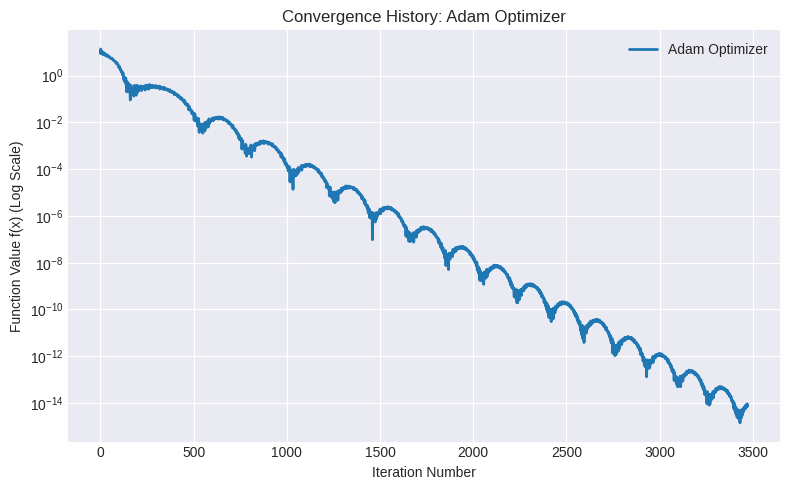

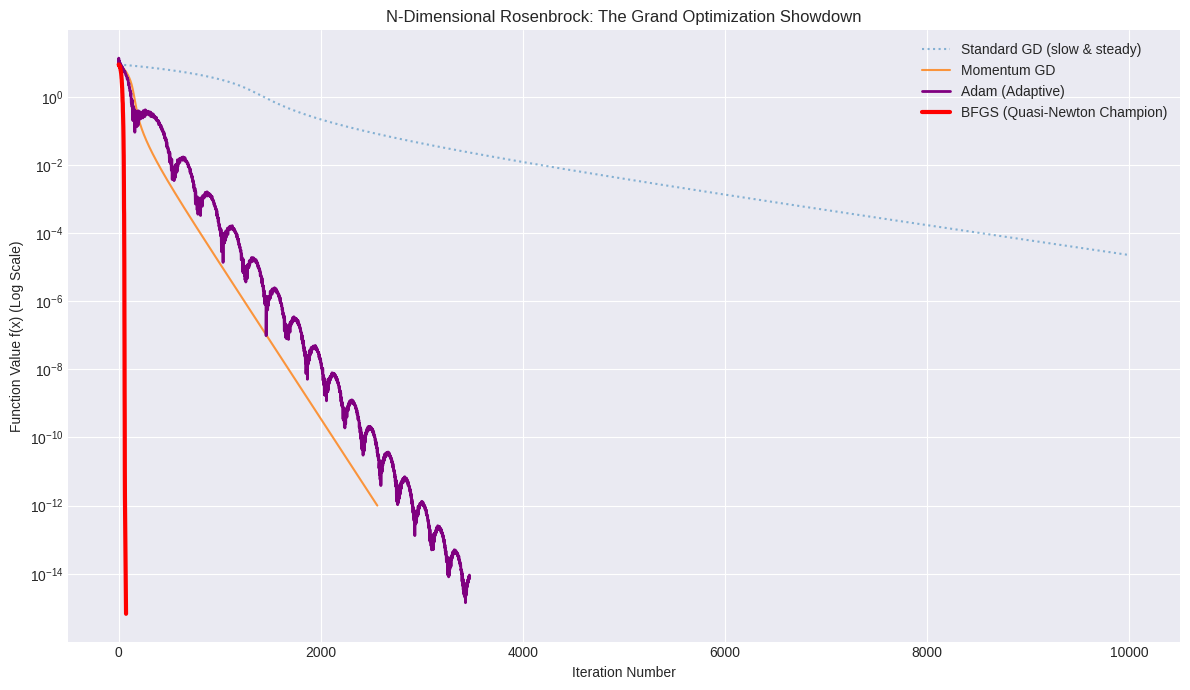

In [16]:
def adam_nd(f, grad_f, x0, step_size=0.01, beta1=0.99, beta2=0.9999, epsilon=1e-8, max_iter=10000, tol=1e-6):
    """N-dimensional Adam optimization."""
    x = np.array(x0, dtype=float)
    
    # Initialize first and second moments to zero
    m = np.zeros_like(x)
    v = np.zeros_like(x)
    
    f_history = [f(x)]
    
    for t in range(1, max_iter + 1):
        grad = grad_f(x)
        
        if np.linalg.norm(grad) < tol:
            print(f"Converged after {t} iterations.")
            break
            
        # 1. Update biased first moment estimate
        m = beta1 * m + (1 - beta1) * grad
        
        # 2. Update biased second raw moment estimate (note the squared gradient)
        v = beta2 * v + (1 - beta2) * (grad ** 2)
        
        # 3. Compute bias-corrected first moment estimate
        m_hat = m / (1 - beta1 ** t)
        
        # 4. Compute bias-corrected second raw moment estimate
        v_hat = v / (1 - beta2 ** t)
        
        # 5. Update position (element-wise division)
        x = x - step_size * m_hat / (np.sqrt(v_hat) + epsilon)
        
        f_history.append(f(x))
        
    else:
        print(f"Reached max iterations ({max_iter}).")
        
    return x, np.array(f_history)

# Execute Adam
# Notice we can use a much larger base step size (0.1) than standard GD (0.001) 
# because Adam automatically scales it down for the steep dimensions!
print("Running Adam Optimizer...")
x_final_adam, history_adam = adam_nd(
    f=rosenbrock_nd, 
    grad_f=rosenbrock_grad_nd, 
    x0=x_start_nd, 
    step_size=0.1, 
    max_iter=10000
)

evaluate_convergence(x_final_adam, history_adam, "Adam Optimizer")

# ---------------------------------------------------------
# The Grand Finale Visualization: All Algorithms Competing
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))
plt.plot(history_gd, label="Standard GD (slow & steady)", alpha=0.5, linestyle=':')
plt.plot(history_mom, label="Momentum GD", alpha=0.8)
plt.plot(history_adam, label="Adam (Adaptive)", linewidth=2, color='purple')
plt.plot(history_bfgs, label="BFGS (Quasi-Newton Champion)", linewidth=3, color='red')

plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Function Value f(x) (Log Scale)')
plt.title('N-Dimensional Rosenbrock: The Grand Optimization Showdown')
plt.legend()
plt.tight_layout()
plt.show()

## The Adam Paradox: Why Did Momentum Win?

If you look closely at the convergence plot, you will notice something surprising: **Momentum often beats Adam on the Rosenbrock function**. If Adam is the most popular optimizer in Machine Learning, why does it lose here?

This exposes a fundamental weakness in how Adam works:

**1. The Coordinate-Wise Scaling Trap**
Adam calculates a separate adaptive learning rate for *every single dimension* ($x_1, x_2, \dots, x_n$). It assumes that scaling the axes independently is a good idea. 
However, the Rosenbrock valley curves diagonally through space; it is not aligned with the $x$ or $y$ axes. By scaling the dimensions independently, Adam actually distorts the true direction of the valley. Momentum, on the other hand, applies a single global learning rate and simply builds up physical velocity in the true direction of the curve.

**2. The Problem with "Flat" Valleys**
As Adam travels down the long, flat floor of the Rosenbrock valley, the gradients become very small. Adam's denominator (the variance) shrinks, which initially causes it to take aggressive, noisy steps. While Momentum smoothly glides like a bobsled down a track, Adam acts like a car constantly micro-adjusting its steering and braking, causing it to stall out before reaching the exact minimum.

**Why use Adam at all?**
In classical optimization (like this N-dimensional function), where we can perfectly tune a single learning rate, **Momentum is king**. 

But in Deep Learning, we are optimizing millions of parameters at once. Some parameters are attached to steep gradients, others to flat ones. Finding one single step size that works for all 1,000,000 parameters (Standard Momentum) is nearly impossible. Adam is the industry standard not because it is the absolute fastest, but because it is **robust**. It finds a "good enough" learning rate for every parameter automatically, requiring very little manual tuning from the engineer.